In [5]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"

print(PROJECT_ROOT)

df = pd.read_parquet(RAW_DIR / "yellow_tripdata_2024-01.parquet")

/workspaces/logistics-ml-platform


In [6]:
df.isna().sum().sort_values(ascending=False)

Airport_fee              140162
congestion_surcharge     140162
passenger_count          140162
RatecodeID               140162
store_and_fwd_flag       140162
extra                         0
total_amount                  0
improvement_surcharge         0
tolls_amount                  0
tip_amount                    0
mta_tax                       0
VendorID                      0
fare_amount                   0
tpep_pickup_datetime          0
DOLocationID                  0
PULocationID                  0
trip_distance                 0
tpep_dropoff_datetime         0
payment_type                  0
dtype: int64

In [7]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,2964624.0,1.754204,1.0,2.0,2.0,2.0,6.0,0.43259
tpep_pickup_datetime,2964624,2024-01-17 00:46:36.431092,2002-12-31 22:59:39,2024-01-09 15:59:19.750000,2024-01-17 10:45:37.500000,2024-01-24 18:23:52.250000,2024-02-01 00:01:15,NaN
tpep_dropoff_datetime,2964624,2024-01-17 01:02:13.208130,2002-12-31 23:05:41,2024-01-09 16:16:23,2024-01-17 11:03:51.500000,2024-01-24 18:40:29,2024-02-02 13:56:52,NaN
passenger_count,2824462.0,1.339281,0.0,1.0,1.0,1.0,9.0,0.850282
trip_distance,2964624.0,3.652169,0.0,1.0,1.68,3.11,312722.3,225.462572
RatecodeID,2824462.0,2.069359,1.0,1.0,1.0,1.0,99.0,9.823219
PULocationID,2964624.0,166.017884,1.0,132.0,162.0,234.0,265.0,63.623914
DOLocationID,2964624.0,165.116712,1.0,114.0,162.0,234.0,265.0,69.31535
payment_type,2964624.0,1.161271,0.0,1.0,1.0,1.0,4.0,0.580869
fare_amount,2964624.0,18.175062,-899.0,8.6,12.8,20.5,5000.0,18.949548


In [8]:
numeric = [
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "passenger_count",
]

for col in numeric:
    print(col)
    print((df[col] < 0).sum())

trip_distance
0
fare_amount
37448
tip_amount
102
total_amount
35504
passenger_count
0


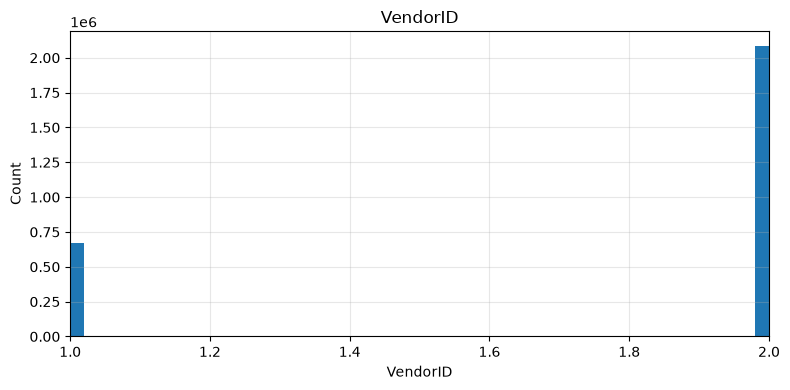

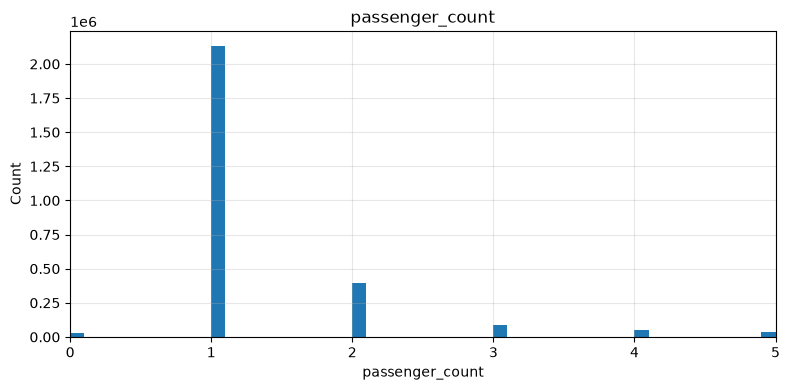

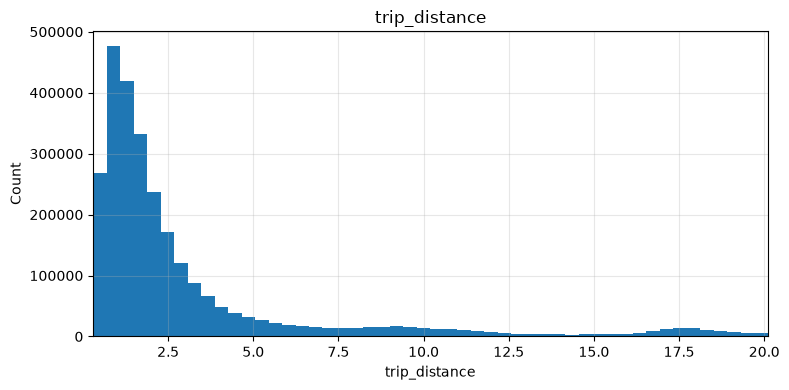

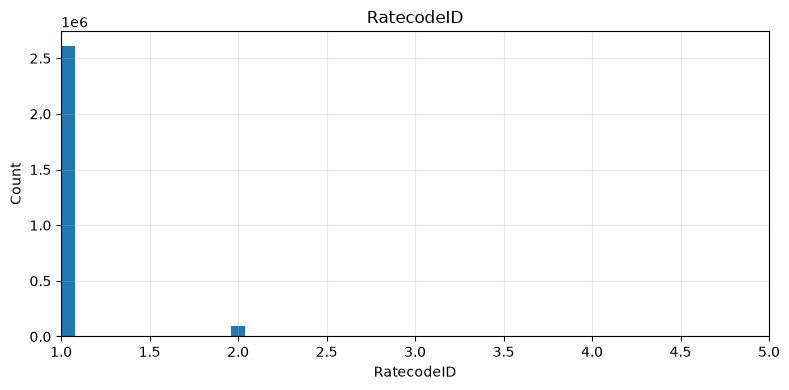

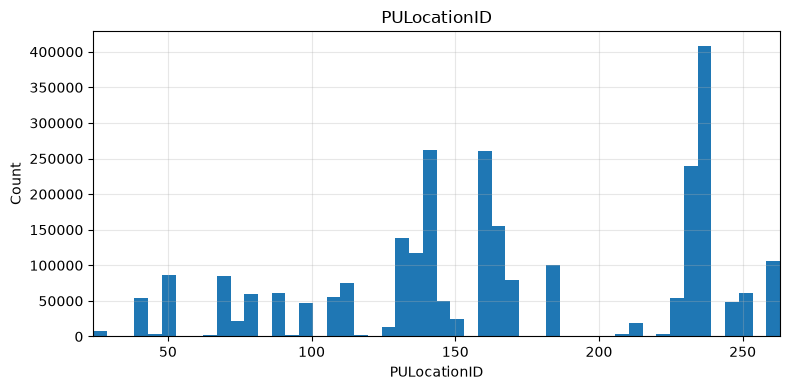

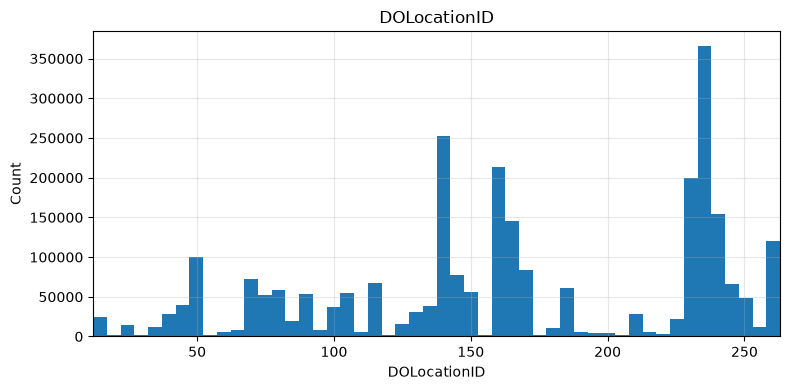

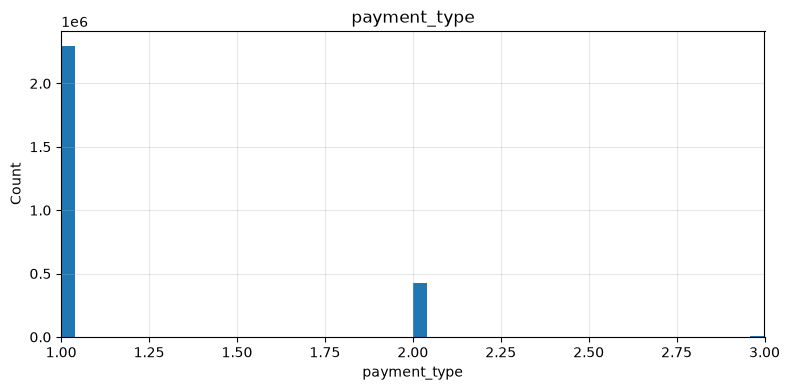

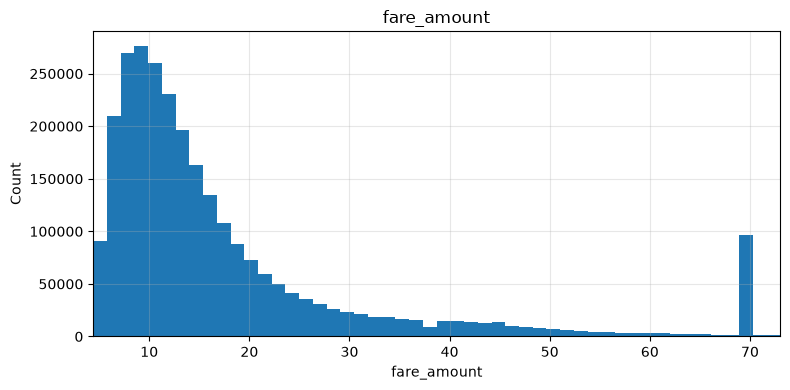

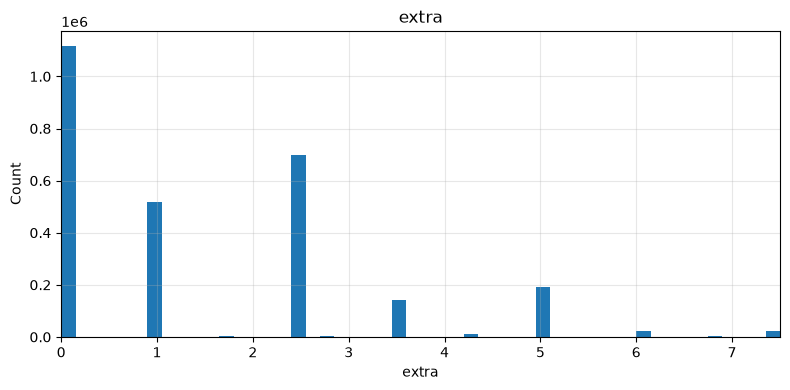

/tmp/ipykernel_121772/2294599466.py:20: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(lower, upper)


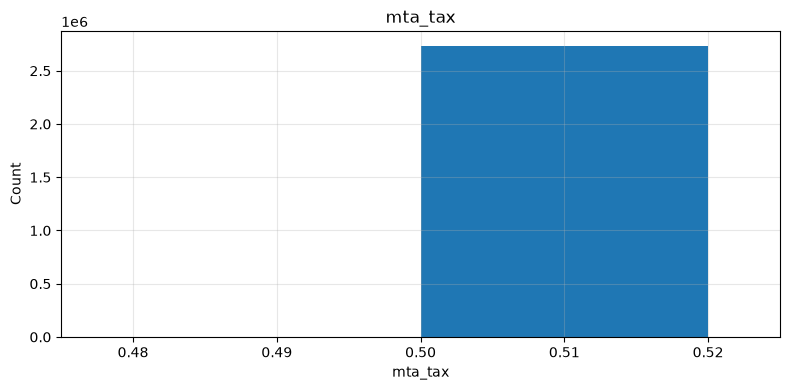

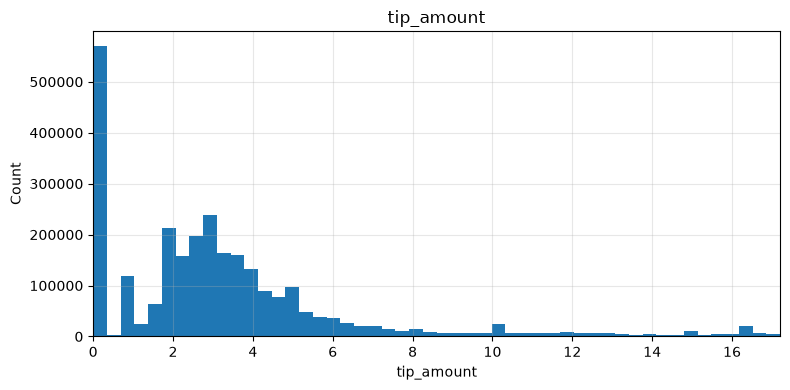

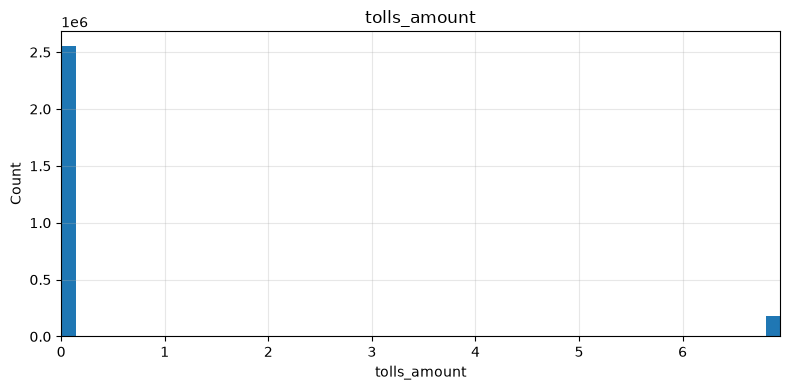

/tmp/ipykernel_121772/2294599466.py:20: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(lower, upper)


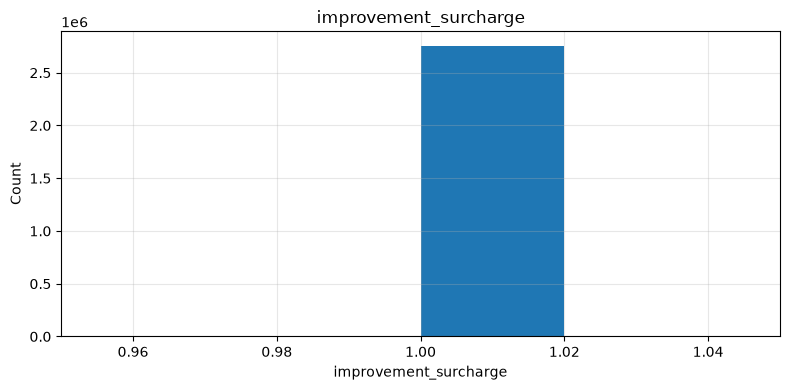

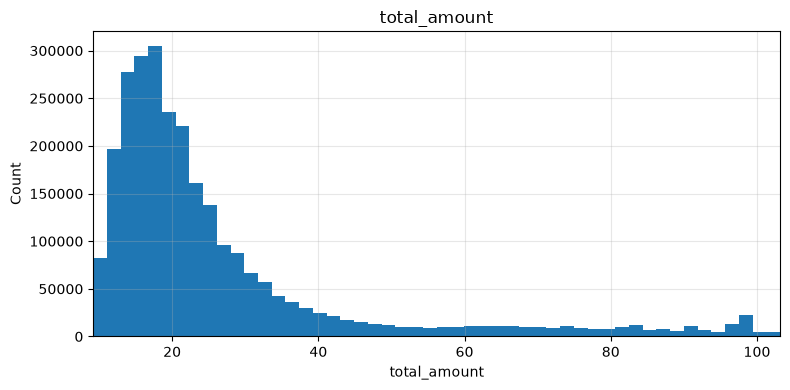

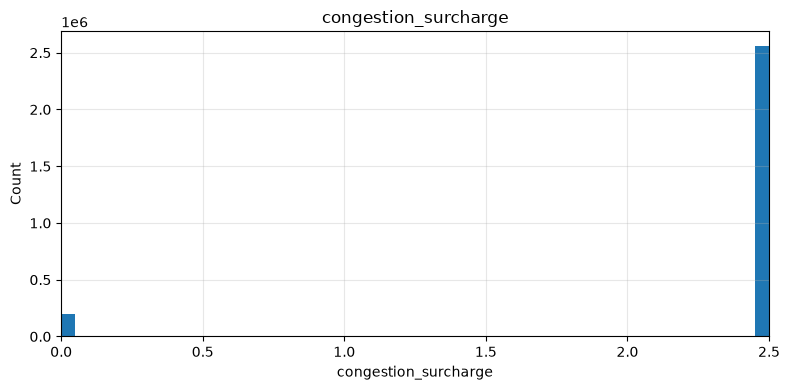

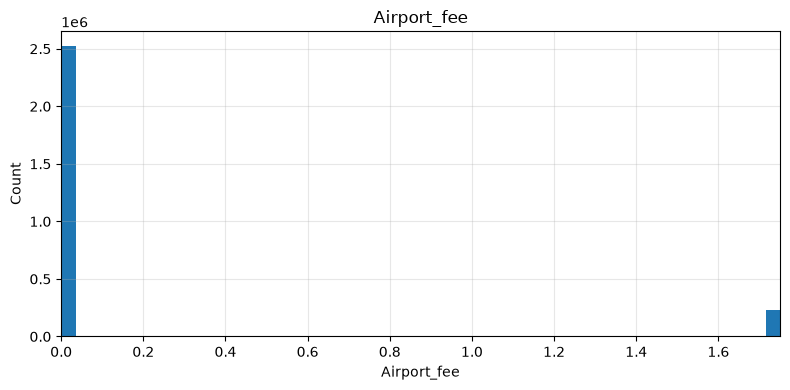

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

numeric = df.select_dtypes(include="number").columns

for col in numeric:
    data = df[col].dropna()

    # Ignore extreme outliers for visualization only
    lower = data.quantile(0.01)
    upper = data.quantile(0.99)

    clipped = data[(data >= lower) & (data <= upper)]

    plt.figure(figsize=(8, 4))
    plt.hist(clipped, bins=50)
    plt.title(f"{col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xlim(lower, upper)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

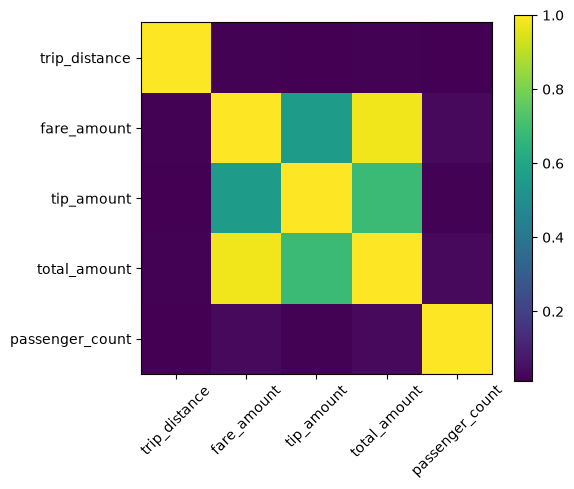

In [10]:
import matplotlib.pyplot as plt

corr = df[numeric].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr)
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.tight_layout()

In [11]:
df = df.drop_duplicates()

df = df[
    (df.trip_distance > 0)
    & (df.total_amount > 0)
    & (df.passenger_count >= 0)
]